# Predict Molecular Property using Recurrent Neural Networks

## Install Dependencies

In [ ]:
!pip install numpy pandas matplotlib seaborn torch torch_geometric rdkit wget tqdm

## Download Dataset

In [2]:
!python -m \
    wget https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv


Saved under delaney-processed (2).csv


## Import Packages

In [3]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import tqdm

mpl.rcParams["font.size"] = 24
mpl.rcParams["lines.linewidth"] = 2

import rdkit.Chem as Chem

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


## Load Dataset

In [5]:
DELANEY_FILE = "delaney-processed.csv"
TASK_COL = 'measured log solubility in mols per litre'
df = pd.read_csv(DELANEY_FILE)
print(f"Number of molecules in the dataset: {df.shape[0]}")

Number of molecules in the dataset: 1128


In [6]:
df["mol"] = df["smiles"].apply(lambda x: Chem.MolFromSmiles(x))
df = df[df["mol"].notna()]

In [7]:
# we will keep the following columns and discard the rest
df = df[["Compound ID", TASK_COL, "smiles", "mol"]]
df

,Compound ID,measured log solubility in mols per litre,smiles,mol
0,Amigdalin,-0.770,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,<rdkit.Chem.rdchem.Mol object at 0x7f69d3dfc660>
1,Fenfuram,-3.300,Cc1occc1C(=O)Nc2ccccc2,<rdkit.Chem.rdchem.Mol object at 0x7f69d3dbd2a0>
2,citral,-2.060,CC(C)=CCCC(C)=CC(=O),<rdkit.Chem.rdchem.Mol object at 0x7f69d33e1cb0>
3,Picene,-7.870,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,<rdkit.Chem.rdchem.Mol object at 0x7f69d33e1a80>
4,Thiophene,-1.330,c1ccsc1,<rdkit.Chem.rdchem.Mol object at 0x7f69d33a2570>
...,...,...,...,...
1123,halothane,-1.710,FC(F)(F)C(Cl)Br,<rdkit.Chem.rdchem.Mol object at 0x7f69d32f4350>
1124,Oxamyl,0.106,CNC(=O)ON=C(SC)C(=O)N(C)C,<rdkit.Chem.rdchem.Mol object at 0x7f69d32f43c0>
1125,Thiometon,-3.091,CCSCCSP(=S)(OC)OC,<rdkit.Chem.rdchem.Mol object at 0x7f69d32f4430>
1126,2-Methylbutane,-3.180,CCC(C)C,<rdkit.Chem.rdchem.Mol object at 0x7f69d32f44a0>


## Create SMILES Dataset

In this notebook, we will use either `rdkit` CanonicalSMILES or augmented SMILES in training.

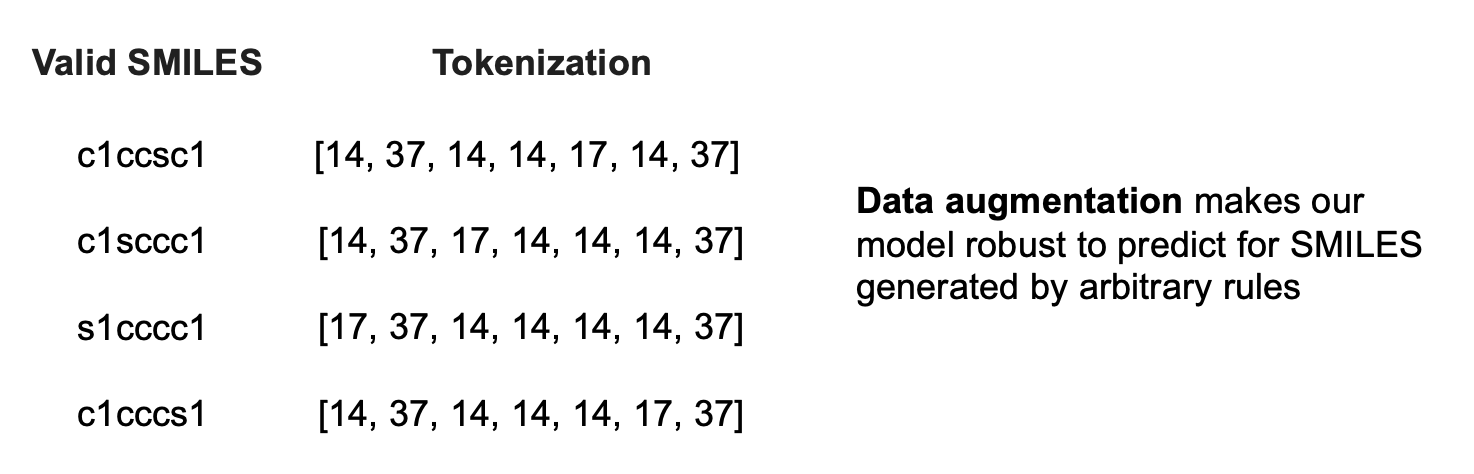

In [8]:
class SMILESDataset(Dataset):
    def __init__(self, df, mol_col, target_col, augment=True):
        self.all_df = df
        self.mol_col = mol_col
        self.target_col = target_col
        self.augment = augment

    def _featurize(self, mol):
        #The mapping of the chemical compounds to SMILES strings are not unique
        # "doRandom" allows the generation of different SMILES strings
        # for the same chemical compounds.
        # This is our data augmentation approach
        smi = Chem.MolToSmiles(mol, doRandom=self.augment)
        return smi

    def __getitem__(self, idx):
        mol = self.all_df.iloc[idx][self.mol_col]
        smi = self._featurize(mol)
        pka = self.all_df.iloc[idx][self.target_col]
        return smi, float(pka)

    def __len__(self):
        return self.all_df.shape[0]

Padding to make all the SMILES strings have the same length 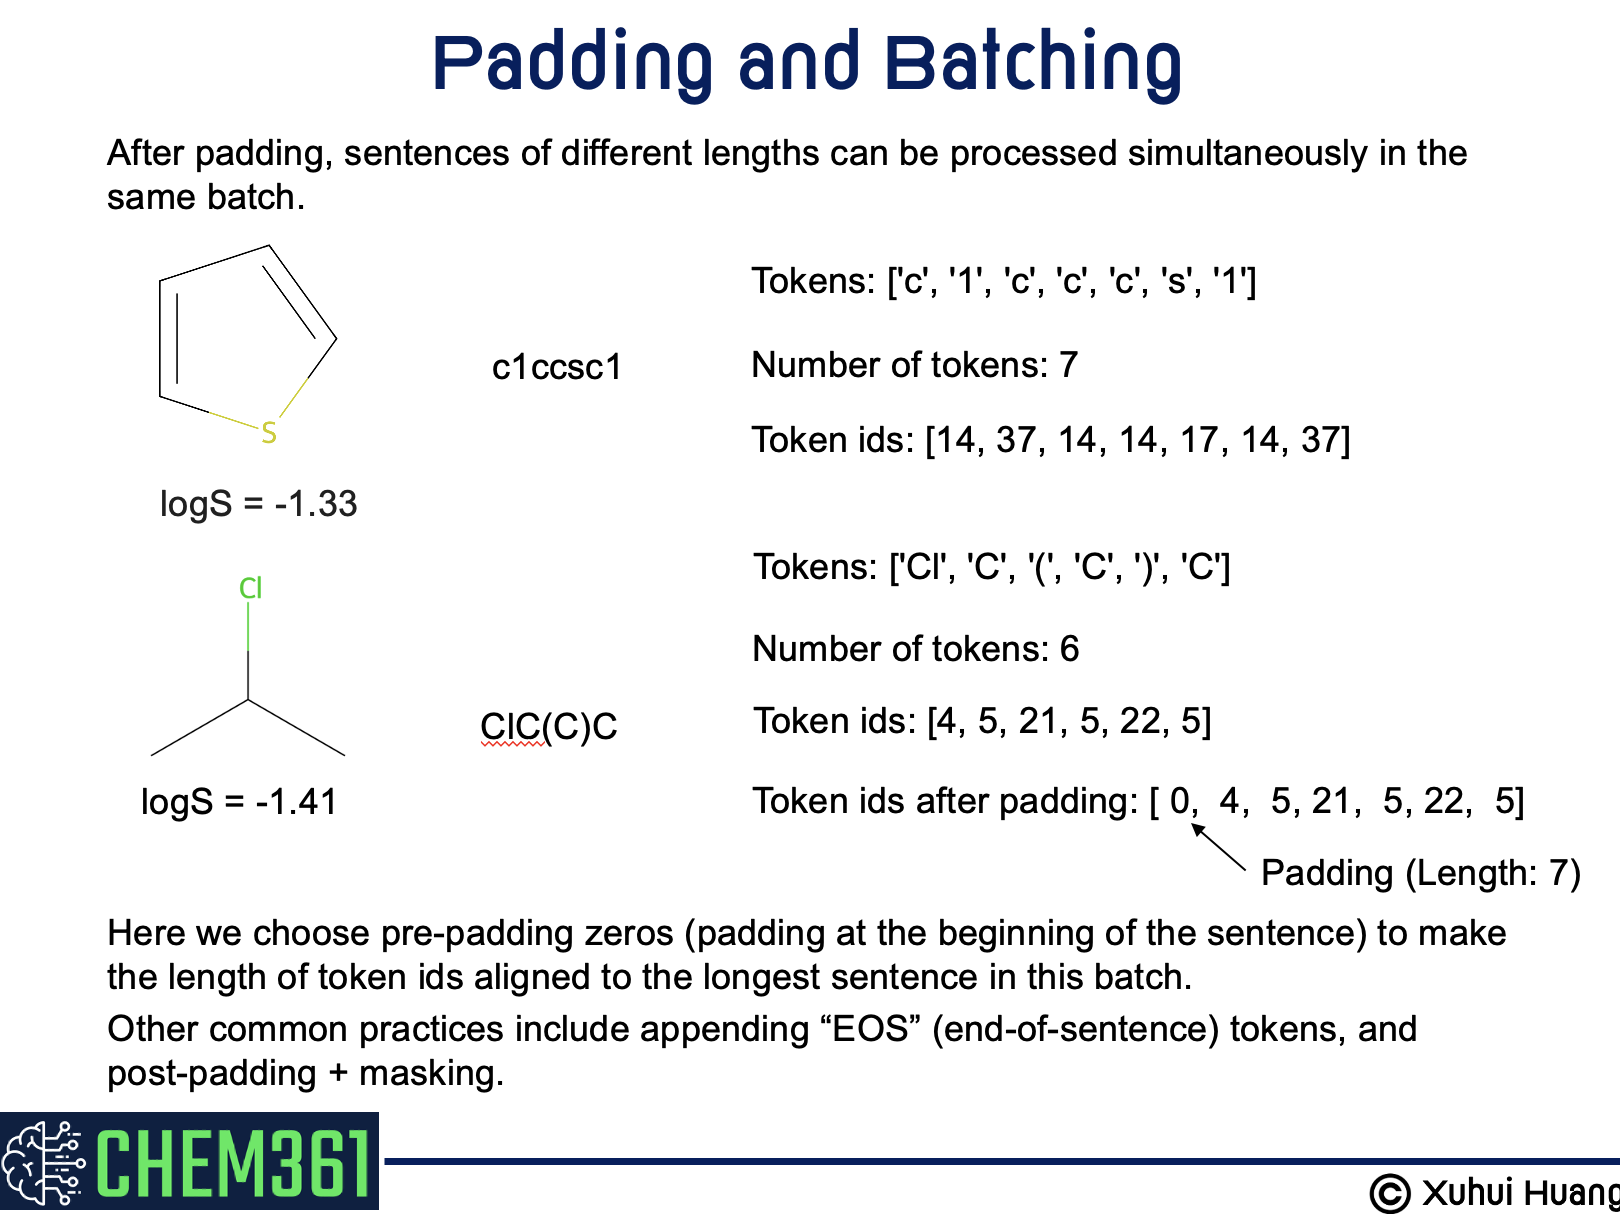

In [9]:
class Collate:
    def __init__(self, tokenizer, pad_token="PAD"):
        self.tokenizer = tokenizer
        self.pad_token = pad_token

    def collate(self, data):
        smis = [smi for smi, pka in data]
        X = [self.tokenizer.encode(smi) for smi in smis]
        max_len = max([len(toks) for toks in X])
        pad_idx = self.tokenizer.token2idx(self.pad_token)
        # padded X
        X = [[pad_idx]*(max_len-len(toks))+list(toks) for toks in X]
        X = torch.Tensor(X).long()
        Y = torch.Tensor([pka for smi, pka in data]).reshape(-1, 1).float()
        return X, Y

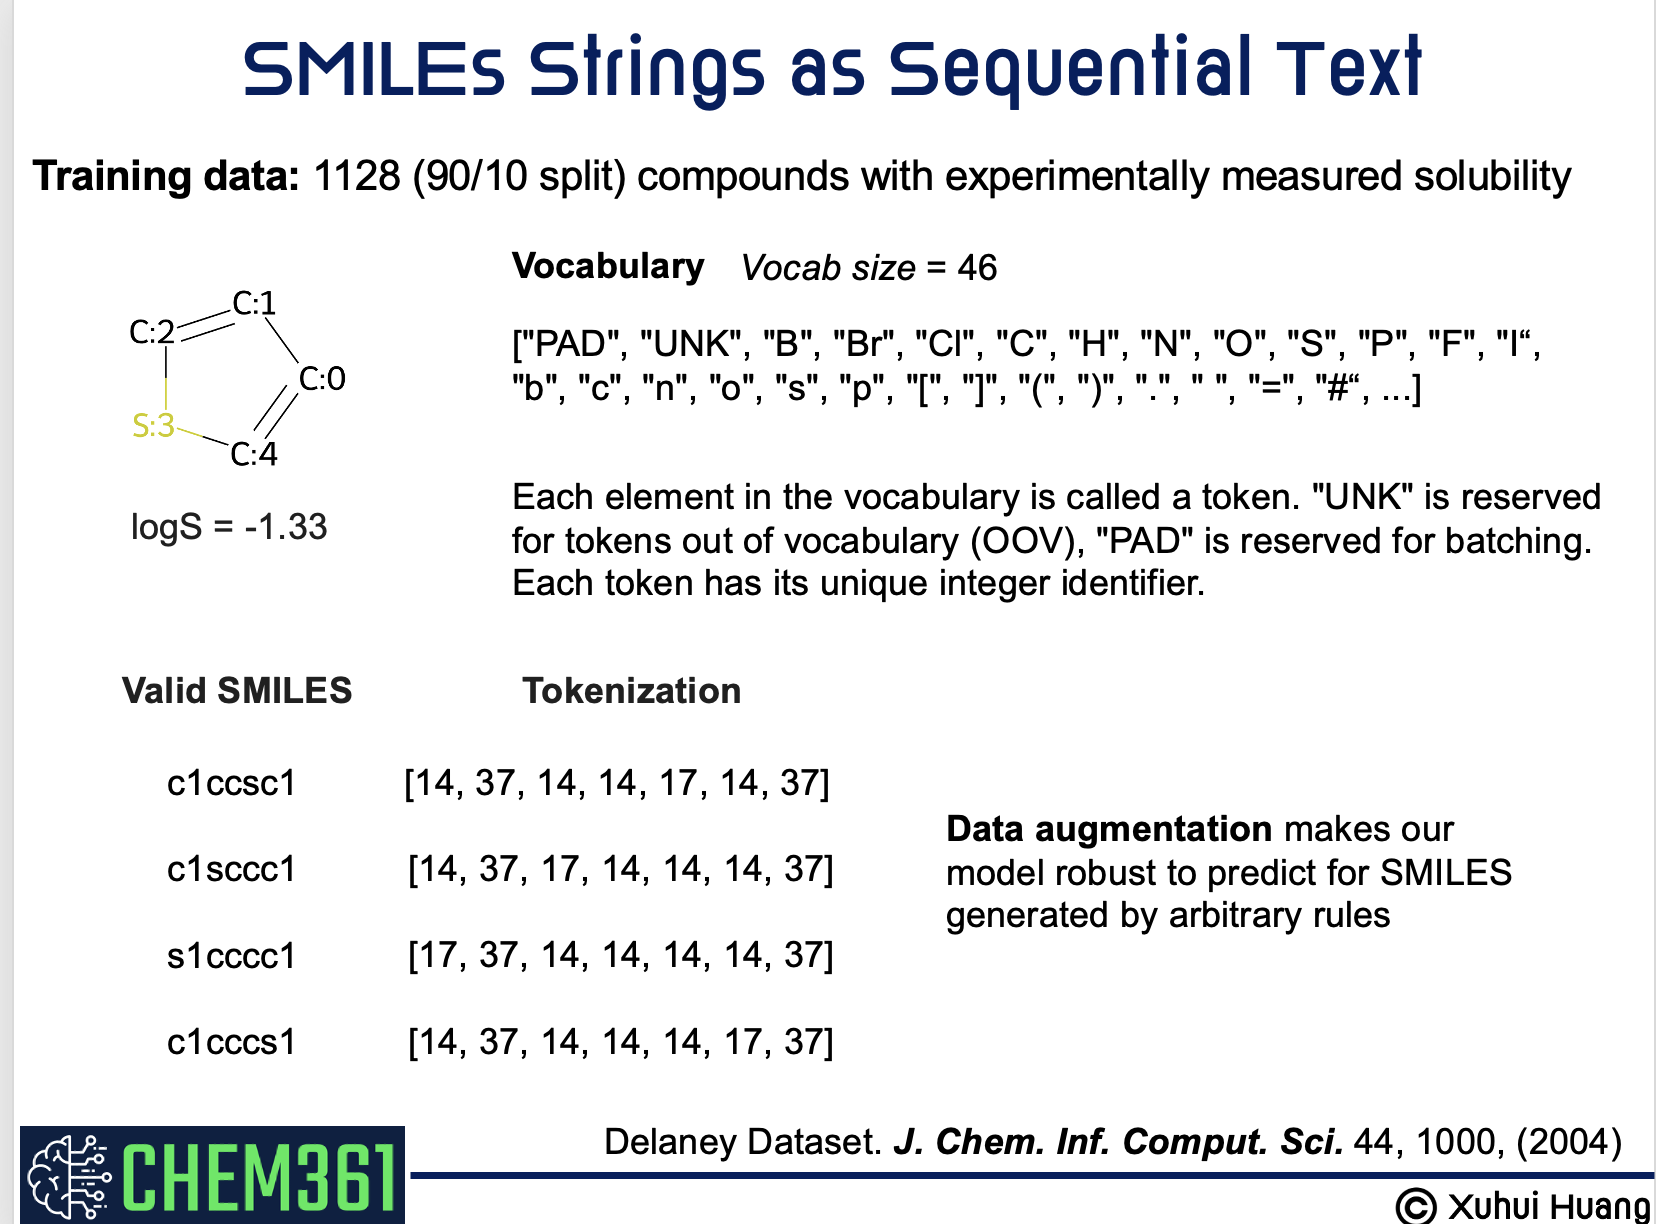

`Tokenizer` converts a SMILE string to a list of integers. The integer $i$ has the same meaning as Onehot Enbedding with the $i$-th position flagged as 1. We just convert to integers to save memory and be more compatible with `nn.Embedding`, which serves as a look-up table that converts the sparse Onehot embedding to a continuous embedding.

In [10]:
# convert characters to integers
class Tokenizer():
    def __init__(self):
        self.vocab = ["PAD", "UNK", "B", "Br", "Cl", "C", "H", \
            "N", "O", "S", "P", "F", "I", \
            "b", "c", "n", "o", "s", "p", "[", "]", \
            "(", ")", ".", " ", "=", "#", \
            "+", "-", ":", "~", "@", "*", "%", \
            "/", "\\", "0", "1", "2", "3", "4", \
            "5", "6", "7", "8", "9"]
        self.i2v = {i: v for i, v in enumerate(self.vocab)}
        self.v2i = {v:i for i, v in enumerate(self.vocab)}


        SMI_REGEX_PATTERN = r"""(\[[^\]]+]|Br?|Cl?|N|O|S|P|F|I|b|c|n|o|s|p|\(|\)|\.|=|
        #|-|\+|\\|\/|:|~|@|\?|>>?|\*|\$|\%[0-9]{2}|[0-9])"""
        self.regex_pattern = SMI_REGEX_PATTERN
        self.regex = re.compile(self.regex_pattern)

    def token2idx(self, v):
        if v in self.vocab:
            return self.v2i[v]
        else:
            return self.v2i["UNK"]

    def encode(self, smi):
        lst = []
        tokens = [token for token in self.regex.findall(smi)]
        for v in tokens:
            lst.append(self.token2idx(v))
        return lst

Example of tokenizing "c1cccs1"

In [11]:
tokenizer = Tokenizer()
# smi = df.iloc[4]["smiles"]
smi = "c1cccs1"
# smi = "ClC(C)C"
print(smi)
tokens = [token for token in tokenizer.regex.findall(smi)]
print("Tokens:", tokens)
tok_ids = tokenizer.encode(smi)
print("Token ids:", tok_ids)

c1cccs1
Tokens: ['c', '1', 'c', 'c', 'c', 's', '1']
Token ids: [14, 37, 14, 14, 14, 17, 37]


Example of padding "c1cccs1"

In [12]:
Collate(tokenizer).collate([("c1cccs1", -1.33), ("ClC(C)C", -1.41)])

(tensor([[14, 37, 14, 14, 14, 17, 37],
         [ 0,  4,  5, 21,  5, 22,  5]]),
 tensor([[-1.3300],
         [-1.4100]]))

## Split Dataset

In [13]:
from sklearn.model_selection import train_test_split

# training/validation dataset
data_size = df.shape[0]
test_ratio = 0.10
test_size = int(data_size*test_ratio)
train_indices, test_indices = train_test_split(range(data_size), test_size=test_size, shuffle=True)
print(f"Training size: {len(train_indices)}, test size: {len(test_indices)}")
train_df, test_df = df.iloc[train_indices], df.iloc[test_indices]

Training size: 1016, test size: 112


In [14]:
# change to False in order to use rdkit CanonicalSMILES only
augment = True
batch_size = 32

tokenizer = Tokenizer()
print(tokenizer.vocab)
vocab_size = len(tokenizer.vocab)
print(f"Number of tokens: {vocab_size}")

## batching
instance = Collate(tokenizer)
collate_fn = instance.collate

train_data = SMILESDataset(train_df, mol_col="mol", target_col=TASK_COL, augment=augment)
train_loader = DataLoader(train_data, \
    batch_size=batch_size, shuffle=True, collate_fn=collate_fn, drop_last=False)
test_data = SMILESDataset(test_df, mol_col="mol", target_col=TASK_COL, augment=augment)
test_loader = DataLoader(test_data, \
    batch_size=batch_size, shuffle=False, collate_fn=collate_fn, drop_last=False)

['PAD', 'UNK', 'B', 'Br', 'Cl', 'C', 'H', 'N', 'O', 'S', 'P', 'F', 'I', 'b', 'c', 'n', 'o', 's', 'p', '[', ']', '(', ')', '.', ' ', '=', '#', '+', '-', ':', '~', '@', '*', '%', '/', '\\', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Number of tokens: 46


Example of calling the "train_data" function to generate a SMILES string and print its assocaited ground truth solubility.

In [15]:
train_data[0]

('c12ccccc2c(ccc1)N', -1.92)

calling the "train_data" function 5 times to generate 5 different SMILES strings for the same compound.

In [16]:
print([train_data[4] for i in range(5)])

[('CC(C(O)C)C', -0.18), ('CC(C)C(O)C', -0.18), ('CC(C(C)C)O', -0.18), ('CC(C(C)C)O', -0.18), ('OC(C)C(C)C', -0.18)]


We will print a small batch to see how the `Dataloader` pad for SMILES of different length. The following block shows that each batch contains two items: X of shape (batch_size, length) and Y of shape (batch_size, 1). length is the length of the longest SMILES in the batch. The other SMILES in the same batch will be padded to this length using 0 (the index of `PAD` in the `Tokenizer`). We will adopt pre-padding in this notebook, which means padding 0's at the beginning.

In [17]:
batch = next(iter(DataLoader(train_data, \
    batch_size=5, shuffle=True, collate_fn=collate_fn, drop_last=False)))
print(batch)

(tensor([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 14, 37, 14, 21,
         14, 21,  4, 22, 14, 14, 14, 37, 22,  7],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 14, 37, 14, 14, 21,
         14, 14, 21, 14, 37,  3, 22,  3, 22,  3],
        [ 5, 37, 38, 21, 11, 22,  5, 39, 21,  5, 22,  5, 25,  5,  5, 21,  5, 25,
          5, 39,  5,  5,  5, 38,  5, 38,  5, 21,  5,  5, 37,  8, 22, 21,  5, 22,
          5, 21,  5, 21,  5, 38, 22,  5, 22, 21,  8, 22,  5, 21, 25,  8, 22,  5,
          8,  5, 21, 25,  8, 22,  5, 22, 25,  8],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0

## Model

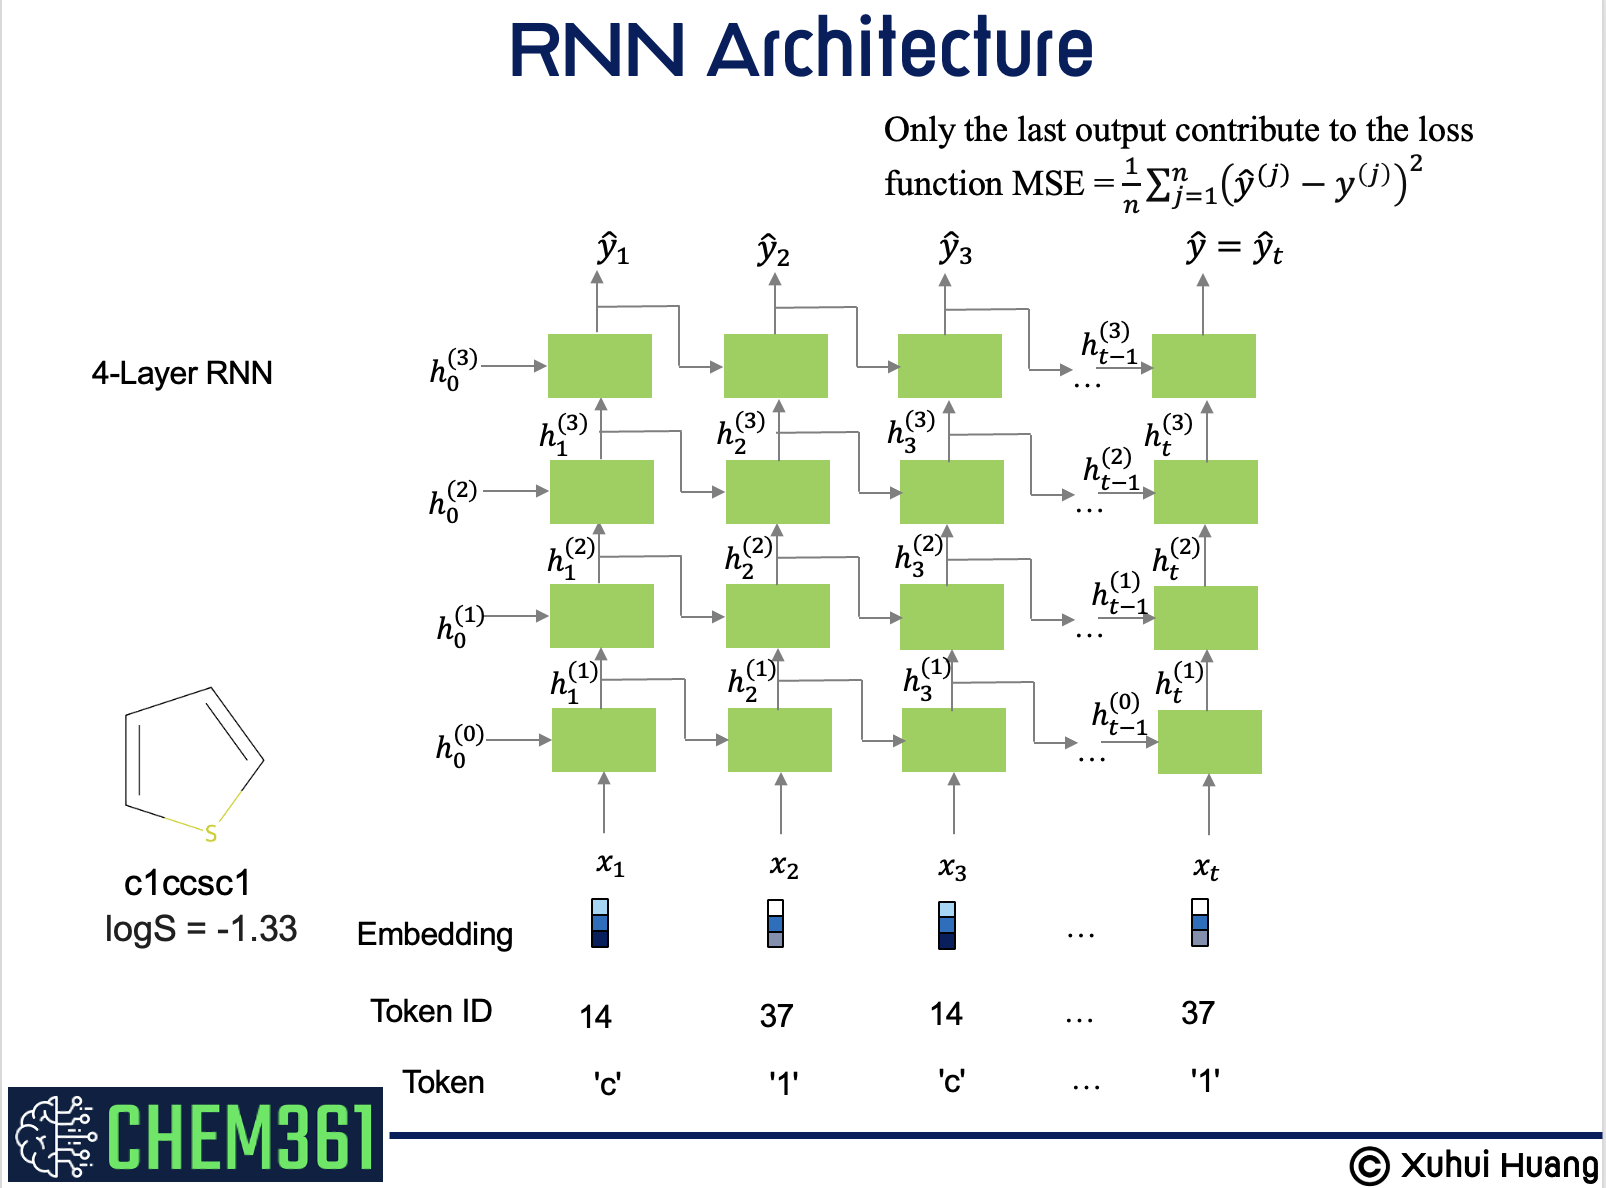

In [18]:
class SMILESModel(nn.Module):
    def __init__(self, vocab_size, emb_dim, \
            hidden_dim, n_layers, dropout=0.3, rnn_type="lstm", bidirectional=True):
        super(SMILESModel, self).__init__()
        #Convert each input token into an "emb_dim" vector.
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.rnn_type = rnn_type
        # choose rnn module
        if self.rnn_type == "rnn":
            self.rnn = nn.RNN(emb_dim, hidden_dim, n_layers, dropout=dropout,
                              batch_first=True, bidirectional=bidirectional)
        elif self.rnn_type == "lstm":
            self.rnn = nn.LSTM(emb_dim, hidden_dim, n_layers, dropout=dropout,
                               batch_first=True, bidirectional=bidirectional)
        elif self.rnn_type == "gru":
            self.rnn = nn.GRU(emb_dim, hidden_dim, n_layers, dropout=dropout,
                              batch_first=True, bidirectional=bidirectional)
        else:
            raise ValueError("rnn_type must be 'rnn', 'lstm', or 'gru'")

        self.dropout = nn.Dropout(dropout)
        if bidirectional:
            self.fc = nn.Linear(2*hidden_dim, 1)
        else:
            self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, token_batch):
        out = token_batch.long()
        out = self.embedding(out) # convert ingeters to continuous embeddings
        out, _ = self.rnn(out)
        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        return out


In [19]:
def train_one_epoch(model, criterion, optimizer, dataloader, clip):
    model.train()
    train_loss = []
    for (x, y) in dataloader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        y_pred = model(x)
        loss = criterion(y_pred, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        train_loss.append(loss.detach().cpu().numpy())
    return np.mean(train_loss)

def val_one_epoch(model, criterion, dataloader):
    model.eval()
    val_loss = []
    with torch.no_grad():
        for (x, y) in dataloader:
            x, y = x.to(device), y.to(device)
            y_pred = model(x)
            loss = criterion(y_pred, y)
            val_loss.append(loss.detach().cpu().numpy())
    return np.mean(val_loss)

## Training

In [20]:
vocab_size = len(Tokenizer().vocab)
lr = 1e-3
emb_dim = 16
hidden_dim = 32
dropout = 0.3
n_layers = 4
clip = 5 # mitigate gradient exploding in BPTT

# bidirectional: run the sentence from "left to right" and from "right to left"
model = SMILESModel(vocab_size, emb_dim, hidden_dim,
                    n_layers, dropout=dropout, rnn_type="rnn", bidirectional=False)
model.to(device)
model = model.float()
print("Number of trainable parameters:",
      sum(p.numel() for p in model.parameters() if p.requires_grad))

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()

n_epochs = 200
train_loss = []
val_loss = []
for epoch in tqdm.tqdm(range(n_epochs)):
    losses = train_one_epoch(model, criterion, optimizer, train_loader, clip)
    train_loss.append(np.mean(losses))
    losses = val_one_epoch(model, criterion, test_loader)
    val_loss.append(np.mean(losses))

Number of trainable parameters: 8705


100%|██████████| 200/200 [01:15<00:00,  2.66it/s]


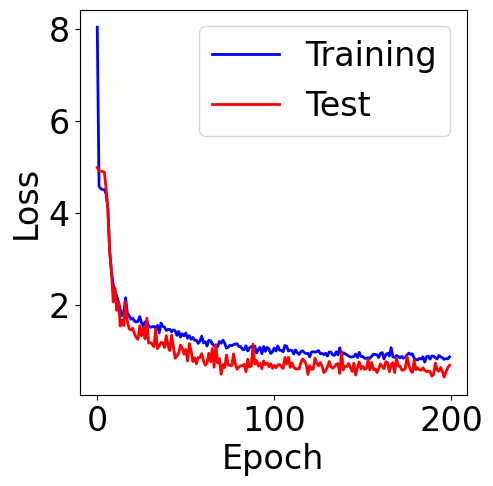

In [21]:
f, ax = plt.subplots(1, 1, figsize=(5,5))

ax.plot(train_loss, c="blue", label="Training")
ax.plot(val_loss, c="red", label="Test")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

## Evaluation Metrics

In [22]:
truths = []
predictions = []
model.eval()
with torch.no_grad():
    for x, y in test_loader:
        if device == "cuda":
            x = x.to(device)
        y_pred = model(x).reshape(-1)
        predictions.extend(y_pred.cpu().detach().numpy().tolist())

        y = y.reshape(y_pred.shape).cpu().numpy().tolist()
        truths.extend(y)

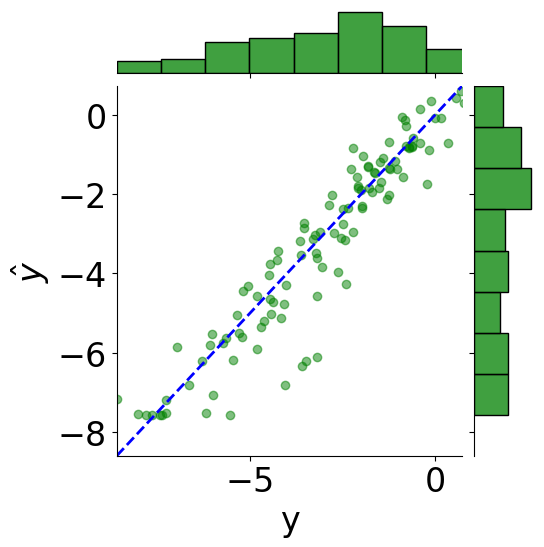

In [23]:
tmp_df = pd.DataFrame({"y": truths, r"$\hat{y}$": predictions})

# scatter plot
g = sns.JointGrid(x="y", y=r"$\hat{y}$", data=tmp_df)
g = g.plot_joint(plt.scatter, c="green", alpha=0.5)

# line: y_pred = y
y_line = np.linspace(np.min(truths), np.max(predictions), 200)
g.ax_joint.plot(y_line, y_line, color="blue", linestyle="--");

# histograms
g = g.plot_marginals(sns.histplot, data=df, color="green", kde=False)

g.ax_joint.set_xlim(np.min(y_line), np.max(y_line))
g.ax_joint.set_ylim(np.min(y_line), np.max(y_line))

plt.show()

In [24]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

print(f"MSE: {mean_squared_error(truths, predictions):.2f}")
print(f"Coefficient of determination: {r2_score(truths, predictions):.2f}")

MSE: 0.68
Coefficient of determination: 0.87
